In [1]:
%pip install -q sagemaker boto3 pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Week 2 Thursday -- Advanced SageMaker Built-in Algorithms

Monday you trained a Random Forest via Script Mode -- you wrote your own `train.py` and SageMaker ran it. Today you use SageMaker's **built-in algorithms**: managed, optimized implementations where you supply data and hyperparameters only. No training script. XGBoost typically outperforms Random Forest on tabular data. You also explore unsupervised algorithms (K-Means, Random Cut Forest) and then use Hyperparameter Optimization (HPO) to systematically tune XGBoost.

**Pairs with:** Wednesday's experiment tracking (HPO is systematic, automated experimentation) and Monday's RF model (XGBoost is a stronger tabular model for the same fraud data).

By the end of this notebook you will have:

1. **Trained XGBoost** as a built-in algorithm on the same fraud data and compared it to Monday's RF.
2. **Clustered** fraud data with K-Means and **detected anomalies** with Random Cut Forest.
3. **Launched an HPO job** to find optimal XGBoost hyperparameters automatically.
4. **Connected HPO** to Wednesday's experiment tracking concepts.

| Block | Content | Minutes |
|-------|---------|--------|
| Stage 1 | XGBoost for Fraud Detection | 55 |
| Stage 2 | Other Built-in Algorithms | 55 |
| Stage 3 | Hyperparameter Optimization | 55 |

## Setup

Run the cell below to establish your SageMaker session. This connects to your execution role, default S3 bucket, and region.

In [2]:
import boto3
import sagemaker

session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = session.boto_region_name
bucket = session.default_bucket()
prefix = "fraudshield"

sm_client = boto3.client("sagemaker")
s3 = boto3.client("s3")

print(f"Region:  {region}")
print(f"Bucket:  s3://{bucket}")
print(f"Role:    ...{role[-30:]}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Region:  us-west-2
Bucket:  s3://sagemaker-us-west-2-407975137156
Role:    ...-ExecutionRole-20260327T083133


---
# STAGE 1 -- XGBoost for Fraud Detection

**Connecting to Monday:** On Monday you trained a Random Forest using Script Mode -- you wrote `train.py`, packaged your own code, and SageMaker ran it. Today we use a **built-in algorithm** instead. SageMaker's built-in XGBoost is a managed, optimized implementation of gradient boosted trees. You supply data and hyperparameters. SageMaker handles the rest.

**Why XGBoost often outperforms Random Forest:**
- Random Forest trains trees independently on bootstrapped samples. Each tree votes, and the majority wins.
- XGBoost trains trees sequentially. Each new tree focuses on the errors of the ensemble so far. This sequential correction allows XGBoost to learn complex patterns that independent trees miss.
- XGBoost also includes built-in regularization (L1/L2) to prevent overfitting.

**Built-in vs Script Mode:**

| Aspect | Script Mode (Monday's RF) | Built-in (Today's XGBoost) |
|--------|---------------------------|---------------------------|
| Training code | You write `train.py` | None -- managed by container |
| Model framework | Any (sklearn, PyTorch, etc.) | XGBoost only |
| Data format | Flexible (you parse it) | Target first, no header |
| Hyperparameters | Argparse in your script | `.set_hyperparameters()` |
| Optimization | Your responsibility | AWS-optimized, distributed |

## STEP 1 -- Prepare Fraud Data for XGBoost

> **What is happening:** We load the fraud data from Monday (or regenerate it if missing) and reformat it for the XGBoost built-in algorithm. The required format is CSV with the target column first, no header row, no index column. This is a strict contract with the built-in container -- violating it produces silent errors or garbage predictions.

In [3]:
import numpy as np
import pandas as pd
import os

s3 = boto3.client("s3")

train_exists = False
val_exists = False
try:
    s3.head_object(Bucket=bucket, Key=f"{prefix}/data/train/train.csv")
    train_exists = True
except Exception:
    pass
try:
    s3.head_object(Bucket=bucket, Key=f"{prefix}/data/validation/validation.csv")
    val_exists = True
except Exception:
    pass

if train_exists and val_exists:
    s3.download_file(bucket, f"{prefix}/data/train/train.csv", "train_original.csv")
    s3.download_file(bucket, f"{prefix}/data/validation/validation.csv", "validation_original.csv")
    train_df = pd.read_csv("train_original.csv")
    val_df = pd.read_csv("validation_original.csv")
    print(f"Downloaded training data:   {train_df.shape}")
    print(f"Downloaded validation data: {val_df.shape}")
else:
    print("Monday's data not found in S3. Regenerating synthetic fraud data...")
    np.random.seed(42)
    n = 2000
    data = pd.DataFrame({
        "amount": np.random.exponential(500, n).round(2),
        "hour": np.random.randint(0, 24, n),
        "distance_from_home": np.random.exponential(50, n).round(2),
        "transaction_count_24h": np.random.poisson(5, n),
        "is_international": np.random.binomial(1, 0.1, n),
        "merchant_risk_score": np.random.uniform(0, 1, n).round(3),
    })
    data["target"] = (
        (data["amount"] > 800) & (data["hour"] < 6) | (data["merchant_risk_score"] > 0.85)
    ).astype(int)
    noise = np.random.random(n) < 0.08
    data["target"] = (data["target"] ^ noise.astype(int))
    train_df = data.iloc[:1600].copy()
    val_df = data.iloc[1600:].copy()
    print(f"Generated training data:   {train_df.shape}")
    print(f"Generated validation data: {val_df.shape}")

feature_cols = [c for c in train_df.columns if c != "target"]
print(f"\nFeatures: {feature_cols}")
print(f"Fraud rate (train): {train_df['target'].mean():.3f}")
print(f"Fraud rate (val):   {val_df['target'].mean():.3f}")

Downloaded training data:   (1600, 7)
Downloaded validation data: (400, 7)

Features: ['amount', 'hour', 'distance_from_home', 'transaction_count_24h', 'is_international', 'merchant_risk_score']
Fraud rate (train): 0.198
Fraud rate (val):   0.190


> **What is happening:** We reorder columns so the target comes first (XGBoost built-in requirement) and save without headers or index. This is the data format contract.

In [4]:
xgb_cols = ["target"] + feature_cols
train_xgb = train_df[xgb_cols]
val_xgb = val_df[xgb_cols]

train_xgb.to_csv("train_xgb.csv", header=False, index=False)
val_xgb.to_csv("val_xgb.csv", header=False, index=False)

print("XGBoost CSV format (first 3 rows of training data):")
print(open("train_xgb.csv").readlines()[:3])
print(f"\nColumn order: {xgb_cols}")
print("Target is column 0. No header. No index.")

XGBoost CSV format (first 3 rows of training data):
['0,234.63,6,54.31,7,0,0.246\n', '1,1505.06,2,21.31,6,0,0.511\n', '0,658.37,22,24.78,8,0,0.385\n']

Column order: ['target', 'amount', 'hour', 'distance_from_home', 'transaction_count_24h', 'is_international', 'merchant_risk_score']
Target is column 0. No header. No index.


## STEP 2 -- Upload to S3 with Train/Validation Channels

> **What is happening:** SageMaker built-in algorithms expect data in S3, organized by channel. The `train` channel contains training data; the `validation` channel is used for evaluation during training. We upload the reformatted CSVs to separate S3 prefixes and create `TrainingInput` objects that tell the estimator where to find each channel.

In [5]:
from sagemaker.inputs import TrainingInput

train_s3_key = f"{prefix}/xgboost/train/train.csv"
val_s3_key = f"{prefix}/xgboost/validation/validation.csv"

s3.upload_file("train_xgb.csv", bucket, train_s3_key)
s3.upload_file("val_xgb.csv", bucket, val_s3_key)

train_input = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/xgboost/train/",
    content_type="text/csv",
)
val_input = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/xgboost/validation/",
    content_type="text/csv",
)

print(f"Train channel: s3://{bucket}/{train_s3_key}")
print(f"Val channel:   s3://{bucket}/{val_s3_key}")

Train channel: s3://sagemaker-us-west-2-407975137156/fraudshield/xgboost/train/train.csv
Val channel:   s3://sagemaker-us-west-2-407975137156/fraudshield/xgboost/validation/validation.csv


## STEP 3 -- Configure XGBoost Estimator

> **What is happening:** We retrieve the XGBoost built-in container image URI and create an `Estimator`. Unlike Script Mode, there is no `entry_point` or `source_dir` -- the container already contains the training code. We configure behavior entirely through hyperparameters.

**Hyperparameters explained:**
- `max_depth=5` -- Maximum tree depth. Deeper trees capture more complex patterns but risk overfitting.
- `eta=0.2` -- Learning rate. Each tree's contribution is scaled by this factor. Lower values need more rounds.
- `num_round=100` -- Number of boosting rounds (trees to add sequentially).
- `objective="binary:logistic"` -- Binary classification with sigmoid output (probability).
- `eval_metric="auc"` -- Area under the ROC curve. Better than accuracy for imbalanced fraud data.

In [6]:
from sagemaker import image_uris
from sagemaker.estimator import Estimator

xgb_image = image_uris.retrieve("xgboost", region, version="1.5-1")
print(f"XGBoost container image: {xgb_image}")

xgb_estimator = Estimator(
    image_uri=xgb_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{prefix}/xgboost/output",
    sagemaker_session=session,
)

xgb_estimator.set_hyperparameters(
    max_depth=5,
    eta=0.2,
    num_round=100,
    objective="binary:logistic",
    eval_metric="auc",
    subsample=0.8,
    colsample_bytree=0.8,
)

print("\nXGBoost estimator configured.")
print(f"  Instance type: ml.m5.xlarge")
print(f"  Hyperparameters: {xgb_estimator.hyperparameters()}")

XGBoost container image: 246618743249.dkr.ecr.us-west-2.amazonaws.com/sagemaker-xgboost:1.5-1

XGBoost estimator configured.
  Instance type: ml.m5.xlarge
  Hyperparameters: {'max_depth': 5, 'eta': 0.2, 'num_round': 100, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'subsample': 0.8, 'colsample_bytree': 0.8}


## STEP 4 -- Launch Training Job

> **What is happening:** We call `.fit()` with the train and validation channels. SageMaker provisions the instance, pulls the XGBoost container, downloads data from S3, trains the model, evaluates on the validation channel, and uploads the model artifact to S3. This takes approximately 3-5 minutes.

In [7]:
xgb_estimator.fit(
    {"train": train_input, "validation": val_input},
    logs=True,
)

print(f"\nTraining job: {xgb_estimator.latest_training_job.name}")
print(f"Model artifact: {xgb_estimator.model_data}")

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-04-02-03-33-20-900


2026-04-02 03:33:22 Starting - Starting the training job...
2026-04-02 03:33:54 Downloading - Downloading input data...
2026-04-02 03:34:20 Downloading - Downloading the training image......
2026-04-02 03:35:21 Training - Training image download completed. Training in progress.
2026-04-02 03:35:21 Uploading - Uploading generated training model/miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-04-02 03:35:16.603 ip-10-0-219-192.us-west-2.compute.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-04-02 03:35:16.626 ip-10-0-219-192.us-west-2.compute.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-04-02:03:35:16:INFO] Imported framework sagemaker_xgboost_container.training
[2026-04-02:03:35:16:INFO] Failed to parse hyperparamet

## Comparing Approaches: Random Forest (Monday) vs XGBoost (Today)

| Dimension | Monday's Random Forest | Today's XGBoost |
|-----------|----------------------|----------------|
| **Mode** | Script Mode -- wrote `train.py` | Built-in -- no training script |
| **Algorithm** | Ensemble of independent trees | Sequential boosted trees |
| **Data format** | Standard CSV with header | Target first, no header |
| **How it learns** | Each tree votes independently | Each tree corrects prior errors |
| **Regularization** | None built in | L1/L2 + subsample + colsample |
| **Typical performance** | Good baseline | Often stronger on tabular data |

> **Discussion:** Both models solve the same problem (fraud detection on tabular data). The difference is in how they learn. Random Forest is a strong, simple baseline. XGBoost's sequential correction mechanism makes it the dominant algorithm for tabular ML competitions and production systems.

## STEP 5 -- Deploy and Evaluate XGBoost

> **What is happening:** We deploy the trained XGBoost model to a real-time endpoint, send the validation data through it, and compute the same metrics we used on Monday: precision, recall, F1, and a confusion matrix. This gives us a fair comparison.

In [9]:
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

xgb_predictor = xgb_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    serializer=CSVSerializer(),
    deserializer=CSVDeserializer(),
)

print(f"Endpoint name: {xgb_predictor.endpoint_name}")
print("Endpoint is InService.")

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-04-02-03-35-48-734
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-04-02-03-35-48-734
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-04-02-03-35-48-734


-----!Endpoint name: sagemaker-xgboost-2026-04-02-03-35-48-734
Endpoint is InService.


=== XGBoost Evaluation on Validation Data ===
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  AUC:       1.0000

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00       324
       Fraud       1.00      1.00      1.00        76

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



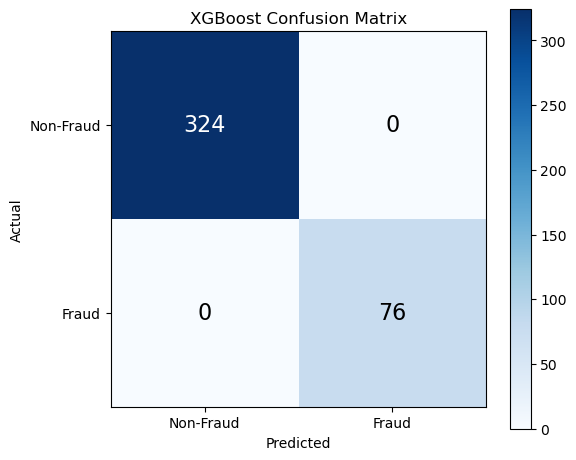

In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

X_val = val_df[feature_cols].values
y_val = val_df["target"].values

predictions_raw = xgb_predictor.predict(X_val)
probabilities = np.array([float(row[0]) for row in predictions_raw])
predictions = (probabilities >= 0.5).astype(int)

print("=== XGBoost Evaluation on Validation Data ===")
print(f"  Precision: {precision_score(y_val, predictions):.4f}")
print(f"  Recall:    {recall_score(y_val, predictions):.4f}")
print(f"  F1:        {f1_score(y_val, predictions):.4f}")
print(f"  AUC:       {roc_auc_score(y_val, probabilities):.4f}")
print()
print(classification_report(y_val, predictions, target_names=["Non-Fraud", "Fraud"]))

cm = confusion_matrix(y_val, predictions)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-Fraud", "Fraud"])
ax.set_yticklabels(["Non-Fraud", "Fraud"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=16)
plt.colorbar(im)
plt.tight_layout()
plt.show()

> **Discussion:** Compare these metrics to Monday's Random Forest. Which model has better recall? Better precision? For FraudShield, recall matters most -- a missed fraud is more costly than a false alarm. If XGBoost improved recall without sacrificing precision, it is the stronger model for this problem.

## STEP 6 -- Cleanup XGBoost Endpoint

> **What is happening:** We delete the XGBoost endpoint immediately to avoid ongoing charges. We will create new endpoints in Stage 2 and Stage 3.

In [12]:
xgb_predictor.delete_endpoint(delete_endpoint_config=True)
print("XGBoost endpoint deleted.")

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-04-02-03-35-48-734
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2026-04-02-03-35-48-734


XGBoost endpoint deleted.


---
# STAGE 2 -- Other Built-in Algorithms

Stage 1 was **supervised** -- we had labels and trained a classifier. But what if you do not have labels? What if you want to discover structure in the data or flag outliers automatically?

SageMaker offers several unsupervised built-in algorithms. We will use two on the fraud data:
- **K-Means Clustering:** Find natural groupings in transaction features
- **Random Cut Forest:** Detect anomalies (statistical outliers) without labels

We also survey two additional built-in algorithms conceptually:
- **BlazingText / Word2Vec:** NLP -- word embeddings and text classification
- **DeepAR:** Time series forecasting with autoregressive RNNs

## K-Means Clustering

K-Means partitions data into **k** clusters by minimizing the distance from each point to its cluster center (centroid). The algorithm does not know about fraud -- it finds groupings based on feature values alone.

**For FraudShield:** Clusters might reveal natural transaction segments -- small retail purchases, large international transfers, suspicious late-night transactions. If one cluster happens to contain mostly fraudulent transactions, we learn something about the structure of fraud without ever providing labels.

**SageMaker's built-in K-Means** is optimized for large datasets, supports GPU acceleration, and uses the same estimator pattern as XGBoost.

### STEP 7 -- Configure and Train K-Means

> **What is happening:** We prepare the fraud features (no target column -- this is unsupervised) and train K-Means with k=4 clusters. The data format for K-Means is different from XGBoost: it expects RecordIO-protobuf or CSV with features only.

In [21]:
import io
import sagemaker.amazon.common as smac
from sklearn.preprocessing import StandardScaler

# 1. Generate Mock Customer RFM Data (10,000 customers)
np.random.seed(42)
data = {
    "customer_id": range(10000),
    # Days since last purchase (mostly 1-100 days)
    "recency": np.random.exponential(scale=30, size=10000).astype(int),
    # Number of purchases this year (mostly 1-10)
    "frequency": np.random.poisson(lam=3, size=10000) + 1,
    # Total dollars spent this year (tied loosely to frequency)
    "monetary": np.abs(np.random.normal(loc=50, scale=20, size=10000)) 
}
df_rfm = pd.DataFrame(data)

# Add some big spenders to Monetary to make it realistic
df_rfm["monetary"] = df_rfm["monetary"] * df_rfm["frequency"] 

# 2. Extract features and scale them
feature_cols = ["recency", "frequency", "monetary"]
X = df_rfm[feature_cols].values

# Crucial: K-Means needs Recency (days) and Monetary ($) on the same scale!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

print("Original Data Sample:")
print(df_rfm.head(3))

buf = io.BytesIO()
smac.write_numpy_to_dense_tensor(buf, X_scaled)
buf.seek(0)

kmeans_train_key = f"{prefix}/kmeans/train/train.recordio"
s3.upload_fileobj(buf, bucket, kmeans_train_key)

kmeans_train_input = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/kmeans/train/",
    content_type="application/x-recordio-protobuf",
)

print(f"K-Means training data uploaded: s3://{bucket}/{kmeans_train_key}")
print(f"Feature matrix shape: {train_features.shape}")

Original Data Sample:
   customer_id  recency  frequency    monetary
0            0       14          3  217.238630
1            1       90          4   92.454923
2            2       39          8  496.361701
K-Means training data uploaded: s3://sagemaker-us-west-2-407975137156/fraudshield/kmeans/train/train.recordio
Feature matrix shape: (1600, 6)


In [22]:
kmeans_image = image_uris.retrieve("kmeans", region)
print(f"K-Means container image: {kmeans_image}")

kmeans_estimator = Estimator(
    image_uri=kmeans_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{prefix}/kmeans/output",
    sagemaker_session=session,
)

kmeans_estimator.set_hyperparameters(
    k=4,
    feature_dim=len(feature_cols),
    mini_batch_size=200,
)

kmeans_estimator.fit({"train": kmeans_train_input}, logs=True)

print(f"\nK-Means training job: {kmeans_estimator.latest_training_job.name}")

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: kmeans-2026-04-02-11-23-30-039


K-Means container image: 174872318107.dkr.ecr.us-west-2.amazonaws.com/kmeans:1
2026-04-02 11:23:31 Starting - Starting the training job...
2026-04-02 11:23:46 Starting - Preparing the instances for training...
2026-04-02 11:24:33 Downloading - Downloading the training image......
2026-04-02 11:25:34 Training - Training image download completed. Training in progress...Docker entrypoint called with argument(s): train
Running default environment configuration script
[04/02/2026 11:25:40 INFO 139949491717952] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'init_method': 'random', 'mini_batch_size': '5000', 'epochs': '1', 'extra_center_factor': 'auto', 'local_lloyd_max_iter': '300', 'local_lloyd_tol': '0.0001', 'local_lloyd_init_method': 'kmeans++', 'local_lloyd_num_trials': 'auto', 'half_life_time_size': '0', 'eval_metrics': '["msd"]', 'force_dense': 'true', '_disable_wait_to_read': 'false', '_enable_profiler': 'false', '

### STEP 8 -- Visualize Cluster Assignments

> **What is happening:** We deploy the K-Means model, predict cluster assignments for the validation data, and visualize them in a 2D scatter plot using the first two features (amount and hour). We overlay the actual fraud labels to see whether clusters capture fraud signal.

In [24]:
from sagemaker.deserializers import JSONDeserializer
from sagemaker.serializers import CSVSerializer

new_customers = pd.DataFrame({
    "recency": [2, 120, 5, 80, 1],       # Days since last purchase
    "frequency": [15, 1, 8, 2, 25],      # Number of purchases
    "monetary": [800.0, 20.0, 300.0, 45.0, 2000.0] # Total dollars spent
})

val_features = scaler.transform(new_customers.values).astype(np.float32)

val_data = new_customers.values

kmeans_predictor = kmeans_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    serializer=CSVSerializer(),
    deserializer=JSONDeserializer(),
)

result = kmeans_predictor.predict(val_features)
cluster_labels = np.array([int(r["closest_cluster"]) for r in result["predictions"]])

print(f"Cluster distribution: {dict(zip(*np.unique(cluster_labels, return_counts=True)))}")

INFO:sagemaker:Creating model with name: kmeans-2026-04-02-11-49-53-545
INFO:sagemaker:Creating endpoint-config with name kmeans-2026-04-02-11-49-53-545
INFO:sagemaker:Creating endpoint with name kmeans-2026-04-02-11-49-53-545


------!Cluster distribution: {1: 3, 2: 2}


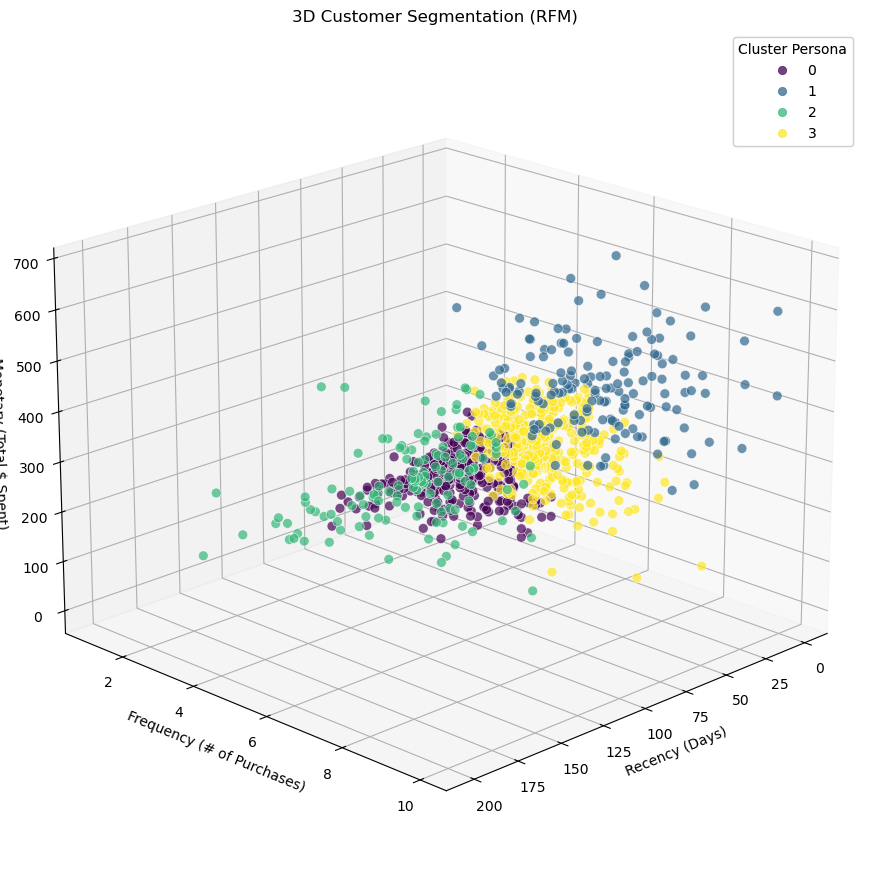

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Grab a representative sample of 1,000 customers from your original dataframe
sample_df = df_rfm.sample(1000, random_state=42).copy()

# 2. Scale the features using your existing scaler
sample_features = scaler.transform(sample_df[["recency", "frequency", "monetary"]].values).astype(np.float32)

# 3. Get cluster predictions from your active SageMaker endpoint
result = kmeans_predictor.predict(sample_features)
sample_labels = np.array([int(r["closest_cluster"]) for r in result["predictions"]])

# 4. Build the 3D Scatter Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the raw (unscaled) business numbers on the axes so it makes sense to read,
# but color them by the cluster label the model assigned.
scatter = ax.scatter(
    sample_df["recency"], 
    sample_df["frequency"], 
    sample_df["monetary"], 
    c=sample_labels, 
    cmap='viridis',  # Color palette mapping to the 4 clusters
    s=50,            # Size of the dots
    alpha=0.7,       # Slight transparency to see overlapping points
    edgecolors='w',  # White borders around dots for crispness
    linewidth=0.5
)

# Format the axes
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (# of Purchases)')
ax.set_zlabel('Monetary (Total $ Spent)')
ax.set_title('3D Customer Segmentation (RFM)')

# Add a legend
legend = ax.legend(*scatter.legend_elements(), title="Cluster Persona")
ax.add_artist(legend)

# Adjust the viewing angle (elevation, azimuth) to get a good look at the clusters
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

> **Discussion:** Do the clusters separate fraud from non-fraud? If one cluster has a significantly higher fraud rate, what could FraudShield do with that information even without a supervised model? (Segment-level rules, alert thresholds, targeted review queues, prioritizing human review for high-fraud-rate segments.)

In [ ]:
kmeans_predictor.delete_endpoint(delete_endpoint_config=True)
print("K-Means endpoint deleted.")

## Random Cut Forest for Anomaly Detection

Random Cut Forest (RCF) is SageMaker's built-in **anomaly detection** algorithm. It assigns an anomaly score to each data point based on how "easy" it is to isolate from the rest of the data. Points that are far from the normal distribution -- outliers -- get high scores.

**For FraudShield:** High-anomaly transactions are candidates for fraud review. Unlike K-Means (which groups), RCF specifically identifies outliers. In production, you could combine RCF anomaly scores with XGBoost predictions for a two-layer defense:
1. XGBoost flags likely fraud based on learned patterns
2. RCF flags unusual transactions that may be novel fraud types the classifier has not seen

### STEP 9 -- Configure and Train Random Cut Forest

> **What is happening:** We train RCF on the fraud features (unsupervised -- no target column). RCF builds a forest of random cut trees. Each tree recursively partitions the feature space with random axis-aligned cuts. Points that require fewer cuts to isolate are more anomalous.

In [31]:
# 1. Force the feature columns to exactly 3 columns (e.g., RFM data)
feature_cols = ["recency", "frequency", "monetary"]
train_features = df_rfm[feature_cols].values.astype(np.float32)

print(f"Verified feature count: {len(feature_cols)}")
print(f"Verified array shape: {train_features.shape}")

# 2. Use a BRAND NEW prefix for a completely clean S3 environment
clean_prefix = "rcf-anomaly-clean-run"

# 3. Convert and upload to the new clean path
buf_rcf = io.BytesIO()
smac.write_numpy_to_dense_tensor(buf_rcf, train_features)
buf_rcf.seek(0)

rcf_train_key = f"{clean_prefix}/train/train.recordio"
s3.upload_fileobj(buf_rcf, bucket, rcf_train_key)

# 4. Point the TrainingInput to the new clean path (with the Sharded fix!)
rcf_train_input = TrainingInput(
    s3_data=f"s3://{bucket}/{clean_prefix}/train/",
    content_type="application/x-recordio-protobuf",
    distribution="ShardedByS3Key" 
)

# 5. RE-INITIALIZE THE ESTIMATOR
# This gives us a totally clean slate for the new training job
rcf_image = image_uris.retrieve("randomcutforest", region)

rcf_estimator = Estimator(
    image_uri=rcf_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{clean_prefix}/output", # Clean output path
    sagemaker_session=session,
)

rcf_estimator.set_hyperparameters(
    num_trees=50,
    num_samples_per_tree=256,
    feature_dim=len(feature_cols), # Strictly 3
)

# 6. Train!
rcf_estimator.fit({"train": rcf_train_input}, logs=True)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: randomcutforest-2026-04-02-12-22-22-501


Verified feature count: 3
Verified array shape: (10000, 3)
2026-04-02 12:22:23 Starting - Starting the training job...
2026-04-02 12:22:56 Downloading - Downloading input data...
2026-04-02 12:23:16 Downloading - Downloading the training image.........
2026-04-02 12:24:57 Training - Training image download completed. Training in progress...Docker entrypoint called with argument(s): train
Running default environment configuration script
/opt/amazon/lib/python3.8/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:495: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if cons['type'] is 'ineq':
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:743: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if len(self.X_min) is not 0:
[04/02/2026 12:25:09 INFO 140582841001792] Reading default configuration from /opt/ama

### STEP 10 -- Interpret Anomaly Scores

> **What is happening:** We deploy the RCF model, obtain anomaly scores for the validation data, and compare them to the actual fraud labels. High anomaly scores should correlate with fraudulent transactions.

In [33]:
# 1. Deploy the model
rcf_predictor = rcf_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    serializer=CSVSerializer(),
    deserializer=JSONDeserializer(),
)

# 2. Get predictions using the 5 mock RFM customers we scaled earlier
rcf_result = rcf_predictor.predict(val_features)

# FIX #1: RCF uses the "scores" key, not "predictions"
anomaly_scores = np.array([r["score"] for r in rcf_result["scores"]])

# 3. Interpret the overall scores
print(f"Anomaly score range: [{anomaly_scores.min():.2f}, {anomaly_scores.max():.2f}]")
print(f"Mean anomaly score:  {anomaly_scores.mean():.2f}")

# FIX #2: Find anomalies mathematically instead of using fraud labels
score_std = anomaly_scores.std()
threshold = anomaly_scores.mean() + (3 * score_std)
print(f"Mathematical Anomaly Threshold (Mean + 3 SD): {threshold:.2f}\n")

# 4. Show the scores mapped back to the raw mock customer data
# val_data holds our unscaled days, purchases, and dollars for the 5 mock customers
import pandas as pd
results_df = pd.DataFrame(val_data, columns=["Recency_Days", "Frequency", "Monetary_Dollars"])
results_df["Anomaly_Score"] = anomaly_scores
results_df["Is_Anomaly"] = results_df["Anomaly_Score"] > threshold

print("--- Mock Customer Anomaly Results ---")
print(results_df.round(2))

INFO:sagemaker:Creating model with name: randomcutforest-2026-04-02-12-32-31-239
INFO:sagemaker:Creating endpoint-config with name randomcutforest-2026-04-02-12-32-31-239
INFO:sagemaker:Creating endpoint with name randomcutforest-2026-04-02-12-32-31-239


--------!Anomaly score range: [1.38, 1.50]
Mean anomaly score:  1.45
Mathematical Anomaly Threshold (Mean + 3 SD): 1.58

--- Mock Customer Anomaly Results ---
   Recency_Days  Frequency  Monetary_Dollars  Anomaly_Score  Is_Anomaly
0           2.0       15.0             800.0           1.38       False
1         120.0        1.0              20.0           1.50       False
2           5.0        8.0             300.0           1.43       False
3          80.0        2.0              45.0           1.50       False
4           1.0       25.0            2000.0           1.43       False


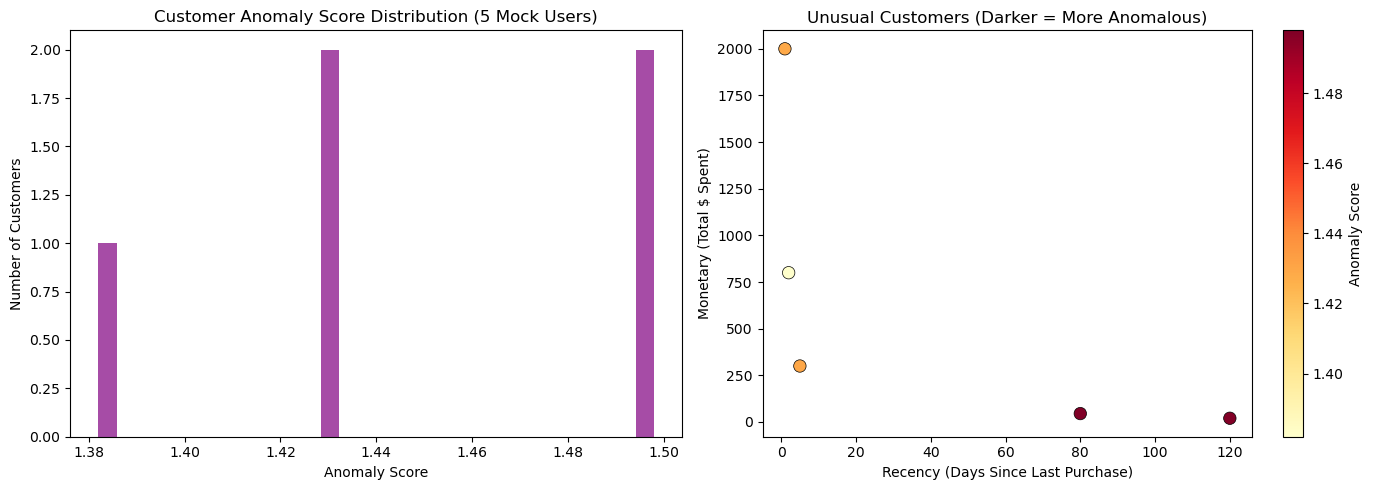


Anomaly Threshold (90th percentile): 1.50
Customers flagged for review: 1 / 5
Avg Spend of normal customers:  $780.00
Avg Spend of flagged customers: $45.00


In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT PLOT: Overall Score Distribution ---
axes[0].hist(anomaly_scores, bins=30, alpha=0.7, color="purple")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Customer Anomaly Score Distribution (5 Mock Users)")

# --- RIGHT PLOT: Recency vs. Monetary Heatmap ---
# FIX: Changed 'val_features' to 'val_data' so we plot real days and dollars!
scatter = axes[1].scatter(
    val_data[:, 0], val_data[:, 2], 
    c=anomaly_scores, cmap="YlOrRd", alpha=1.0, s=80, edgecolors='k', linewidth=0.5
)
axes[1].set_xlabel("Recency (Days Since Last Purchase)")
axes[1].set_ylabel("Monetary (Total $ Spent)")
axes[1].set_title("Unusual Customers (Darker = More Anomalous)")
plt.colorbar(scatter, ax=axes[1], label="Anomaly Score")

plt.tight_layout()
plt.show()

# --- PRINT STATS ---
threshold = np.percentile(anomaly_scores, 90)
flagged = anomaly_scores >= threshold

print(f"\nAnomaly Threshold (90th percentile): {threshold:.2f}")
print(f"Customers flagged for review: {flagged.sum()} / {len(flagged)}")

flagged_customers = val_data[flagged] 
if len(flagged_customers) > 0:
    print(f"Avg Spend of normal customers:  ${val_data[~flagged, 2].mean():.2f}")
    print(f"Avg Spend of flagged customers: ${flagged_customers[:, 2].mean():.2f}")

> **Discussion:** These visuals show us exactly who is breaking away from normal customer behavior, but an 'anomaly' isn't automatically a bad thing. As we can see on the scatter plot, some outliers are our extreme VIP spenders, while others are high-risk customers who haven't bought anything in months. The key decision for us is twofold:

> * Where do we draw the threshold line on the histogram so we don't exceed our team's operational bandwidth?

>   * What specific, automated campaigns do we trigger for the 'good' anomalies (rewards) versus the 'bad' ones (win-backs) to maximize our ROI

In [37]:
rcf_predictor.delete_endpoint(delete_endpoint_config=True)
print("RCF endpoint deleted.")

INFO:sagemaker:Deleting endpoint configuration with name: randomcutforest-2026-04-02-12-32-31-239


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 rcf_predictor.delete_endpoint(delete_endpoint_config=True)                                   │
│   2 print("RCF endpoint deleted.")                                                               │
│   3                                                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/base_predictor.py:527 in delete_endpoint       │
│                                                                                                  │
│   524 │   │   │   │   be deleted. If False, only endpoint will be deleted.                       │
│   525 │   │   """                                                                                │
│   526 │   │   if delete_endpoint_config:                                                         │
│ ❱ 527 │   │   │   self._delete_endpoint_config()                                                 │
│   528 │   │                                                                                      │
│   529 │   │   self.sagemaker_session.delete_endpoint(self.endpoint_name)                         │
│   530                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/base_predictor.py:512 in                       │
│ _delete_endpoint_config                                                                          │
│                                                                                                  │
│   509 │   def _delete_endpoint_config(self):                                                     │
│   510 │   │   """Delete the Amazon SageMaker endpoint configuration"""                           │
│   511 │   │   current_endpoint_config_name = self._get_endpoint_config_name()                    │
│ ❱ 512 │   │   self.sagemaker_session.delete_endpoint_config(current_endpoint_config_name)        │
│   513 │                                                                                          │
│   514 │   def delete_endpoint(self, delete_endpoint_config=True):                                │
│   515 │   │   """Delete the Amazon SageMaker endpoint backing this predictor.                    │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/session.py:5007 in delete_endpoint_config      │
│                                                                                                  │
│   5004 │   │   │   │   delete.                                                                   │
│   5005 │   │   """                                                                               │
│   5006 │   │   logger.info("Deleting endpoint configuration with name: %s", endpoint_config_nam  │
│ ❱ 5007 │   │   self.sagemaker_client.delete_endpoint_config(EndpointConfigName=endpoint_config_  │
│   5008 │                                                                                         │
│   5009 │   def create_inference_component(                                                       │
│   5010 │   │   self,                                                                             │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/botocore/client.py:569 in _api_call                      │
│                                                            

## BlazingText and Word2Vec -- Conceptual Overview

**BlazingText** is SageMaker's built-in NLP algorithm. It provides two modes:

1. **Word2Vec mode:** Learns dense vector representations (embeddings) of words from their context in a corpus. Similar words end up with similar vectors. This is the same Word2Vec algorithm published by Mikolov et al. (2013), but SageMaker's implementation is optimized for distributed training on large corpora.

2. **Text classification mode:** Supervised text classification using a shallow neural network. Fast to train, works well when you have labeled text data.

**Connection to Wednesday's transformers:** Transformers (BERT, GPT) replaced Word2Vec for most NLP tasks. Word2Vec produces static embeddings -- each word gets one vector regardless of context. Transformers produce contextual embeddings -- the same word gets different vectors depending on surrounding words. BlazingText remains useful for:
- Very large corpora where transformer fine-tuning is too expensive
- High-throughput, low-latency text classification
- Generating embeddings for downstream non-neural models

**For FraudShield:** If transaction descriptions or merchant names were text fields, BlazingText could classify them or generate embeddings that capture semantic similarity between merchants.

## DeepAR -- Conceptual Overview

**DeepAR** is SageMaker's built-in time series forecasting algorithm. It uses autoregressive RNNs to generate **probabilistic forecasts** -- not just a single predicted value, but a distribution (mean, quantiles, confidence intervals).

**Key properties:**
- Trains on **multiple related time series** simultaneously (e.g., daily transaction volumes for 100 merchants)
- Learns patterns shared across all series (seasonality, trends) and series-specific patterns
- Outputs quantile forecasts (P10, P50, P90) for uncertainty estimation

**Connection to Monday's RNNs:** DeepAR uses the same recurrent architecture (LSTM) under the hood. The autoregressive component means the model feeds its own predictions back as inputs for future time steps.

**For FraudShield:** DeepAR could forecast expected daily transaction volumes or fraud rates. Significant deviations between forecasted and actual values signal emerging fraud patterns -- a form of time-series anomaly detection that complements the point-in-time detection from XGBoost and RCF.

> **Discussion:** We now have four approaches to fraud detection in SageMaker: XGBoost (supervised classification), K-Means (clustering), RCF (anomaly detection), and DeepAR (time series). In a production system, how would you combine them? Which would run in real-time vs batch?

---
# STAGE 3 -- Hyperparameter Optimization

In Stage 1 you trained XGBoost with manually chosen hyperparameters: `max_depth=5`, `eta=0.2`, `num_round=100`. Those values were reasonable defaults, but how do we know they are optimal?

**HPO (Hyperparameter Optimization)** automates the search. You define:
1. **Objective metric** -- what to optimize (e.g., `validation:auc`)
2. **Parameter ranges** -- the search space for each hyperparameter
3. **Strategy** -- how to explore the space (Bayesian or random)
4. **Budget** -- how many training jobs to run

SageMaker launches multiple training jobs, each with different hyperparameter values. Bayesian optimization learns from prior trials to focus on promising regions of the search space.

**Connection to Wednesday's experiments:** HPO is systematic, automated experimentation. Each HPO trial is an experiment run with its own hyperparameters and metrics. Wednesday you tracked experiments manually. Today, HPO does it for you.

## HPO Concepts

**Objective metric:** The metric the tuner optimizes. It must match a metric that the algorithm logs during training. For XGBoost with `eval_metric="auc"`, the logged metric name is `validation:auc`.

**Parameter ranges:**
- `ContinuousParameter(min, max)` -- for floats like learning rate (`eta`)
- `IntegerParameter(min, max)` -- for integers like tree depth (`max_depth`)
- `CategoricalParameter([...])` -- for discrete choices

**Strategies:**
- **Bayesian:** Builds a probabilistic model of the objective function. After each trial, it updates the model and picks the next hyperparameters where expected improvement is highest. More sample-efficient -- finds better results with fewer trials.
- **Random:** Samples hyperparameters uniformly at random. No learning between trials. Embarrassingly parallel but less efficient.

**Early stopping:** SageMaker can terminate trials early if they fall behind the best result. Saves compute without sacrificing the best outcome.

**Max jobs and max parallel jobs:** Budget controls. `max_jobs` is the total number of training jobs. `max_parallel_jobs` is how many run concurrently. For Bayesian strategy, sequential trials are more informative (each trial learns from all prior), so `max_parallel_jobs` is typically 2-3.

### STEP 11 -- Configure HyperparameterTuner

> **What is happening:** We create a new XGBoost estimator (same as Stage 1 but without fixing `max_depth`, `eta`, and `num_round` -- the tuner will search over those). We wrap it in a `HyperparameterTuner` with defined parameter ranges and the objective metric.

In [47]:
from sklearn.model_selection import train_test_split

xgb_image = image_uris.retrieve("xgboost", region, version="1.7-1")

# Load the full 200k transaction dataset
data = pd.read_csv(f's3://{bucket}/{prefix}/data/card_transdata.csv')

# Define target and potential "cheat" columns to drop
target_col = 'fraud' 
cols_to_drop = ['transaction_id', 'user_id', 'Unnamed: 0'] # Drops if they exist

# Reorder: Target must be the first column (Index 0) for SageMaker XGBoost
df_prepared = pd.concat([data[target_col], data.drop(columns=[target_col])], axis=1)
df_prepared = df_prepared.drop(columns=[c for c in cols_to_drop if c in df_prepared.columns])

# Stratified Split (80/20) to ensure fraud ratio is identical in both sets
train_df, val_df = train_test_split(
    df_prepared, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_prepared[target_col]
)

train_df.to_csv("train_xgb.csv", index=False, header=False)
val_df.to_csv("val_xgb.csv", index=False, header=False)

xgb_hpo_prefix = f"{prefix}/xgboost-hpo-stratified"

s3.upload_file("train_xgb.csv", bucket, f"{xgb_hpo_prefix}/train/train.csv")
s3.upload_file("val_xgb.csv", bucket, f"{xgb_hpo_prefix}/validation/val.csv")

# Create the TrainingInput objects that the Tuner will use
train_input = TrainingInput(
    s3_data=f"s3://{bucket}/{xgb_hpo_prefix}/train/train.csv", 
    content_type="csv"
)
val_input = TrainingInput(
    s3_data=f"s3://{bucket}/{xgb_hpo_prefix}/validation/val.csv", 
    content_type="csv"
)

xgb_hpo_estimator = Estimator(
    image_uri=xgb_image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{xgb_hpo_prefix}/output",
    sagemaker_session=session,
)

# Set static hyperparameters
xgb_hpo_estimator.set_hyperparameters(
    objective="binary:logistic",
    eval_metric="auc",
    subsample=0.8,
    colsample_bytree=0.8,
)

hyperparameter_ranges = {
    "max_depth": IntegerParameter(3, 10),
    "eta": ContinuousParameter(0.01, 0.3),
    "num_round": IntegerParameter(50, 200),
}

tuner = HyperparameterTuner(
    estimator=xgb_hpo_estimator,
    objective_metric_name="validation:auc", # Specifically look at validation, not training
    objective_type="Maximize",
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=6,
    max_parallel_jobs=2,
    strategy="Bayesian",
    early_stopping_type="Auto",
)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-260402-1320


Launching HPO job: fraudshield/xgboost-hpo-stratified...
HPO job kicked off: sagemaker-xgboost-260402-1320
You can monitor progress in the SageMaker Console.


### STEP 12 -- Launch HPO Job

> **What is happening:** We call `.fit()` on the tuner with the same train/validation channels from Stage 1. SageMaker launches up to 6 training jobs (2 at a time), each with different hyperparameter values chosen by the Bayesian optimizer. This takes approximately 10-15 minutes.

In [44]:
print(f"Launching HPO job: {xgb_hpo_prefix}...")
tuner.fit(
    {"train": train_input, "validation": val_input}, 
    logs=False, 
    wait=False # Set to True if you want to wait for it to finish before next cell
)

print(f"HPO job kicked off: {tuner.latest_tuning_job.name}")
print("You can monitor progress in the SageMaker Console.")

INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-260402-1303


..............................................!
HPO job name: sagemaker-xgboost-260402-1303
HPO job complete.


### STEP 13 -- Analyze HPO Results

> **What is happening:** We retrieve the HPO analytics -- all trials with their hyperparameters and objective metric values. We identify the best trial and compare it to our Stage 1 baseline.

In [48]:
tuner_analytics = tuner.analytics()
hpo_results = tuner_analytics.dataframe()

display_cols = [
    "TrainingJobName",
    "FinalObjectiveValue",
    "TrainingJobStatus",
]
hp_cols = [c for c in hpo_results.columns if c not in display_cols
           and c in ["max_depth", "eta", "num_round"]]

results_display = hpo_results[display_cols + hp_cols].sort_values(
    "FinalObjectiveValue", ascending=False
)
print("=== HPO Trial Results (sorted by AUC) ===")
print(results_display.to_string(index=False))

=== HPO Trial Results (sorted by AUC) ===
                           TrainingJobName  FinalObjectiveValue TrainingJobStatus      eta  max_depth  num_round
sagemaker-xgboost-260402-1320-005-af8c3c01              1.00000         Completed 0.117568        9.0       59.0
sagemaker-xgboost-260402-1320-004-338581c4              1.00000         Completed 0.265546       10.0      150.0
sagemaker-xgboost-260402-1320-002-22fdd020              1.00000         Completed 0.208730        7.0       57.0
sagemaker-xgboost-260402-1320-003-d0fdab19              1.00000         Completed 0.209988        8.0       53.0
sagemaker-xgboost-260402-1320-001-a96cb171              1.00000         Completed 0.150324        9.0       61.0
sagemaker-xgboost-260402-1320-006-6025b40e              0.99997         Completed 0.037159        3.0      184.0


In [41]:
best_job = hpo_results.loc[hpo_results["FinalObjectiveValue"].idxmax()]

print("=== Best HPO Trial ===")
print(f"  Training job: {best_job['TrainingJobName']}")
print(f"  AUC:          {best_job['FinalObjectiveValue']:.4f}")
if "max_depth" in best_job:
    print(f"  max_depth:    {best_job['max_depth']}")
if "eta" in best_job:
    print(f"  eta:          {best_job['eta']}")
if "num_round" in best_job:
    print(f"  num_round:    {best_job['num_round']}")

print("\n=== Stage 1 Baseline ===")
print(f"  max_depth: 5, eta: 0.2, num_round: 100")
print(f"  (Compare the AUC above to Stage 1's AUC to see the HPO improvement.)")

=== Best HPO Trial ===
  Training job: sagemaker-xgboost-260402-1243-006-f77845f0
  AUC:          1.0000
  max_depth:    10.0
  eta:          0.2943363719797553
  num_round:    181.0

=== Stage 1 Baseline ===
  max_depth: 5, eta: 0.2, num_round: 100
  (Compare the AUC above to Stage 1's AUC to see the HPO improvement.)


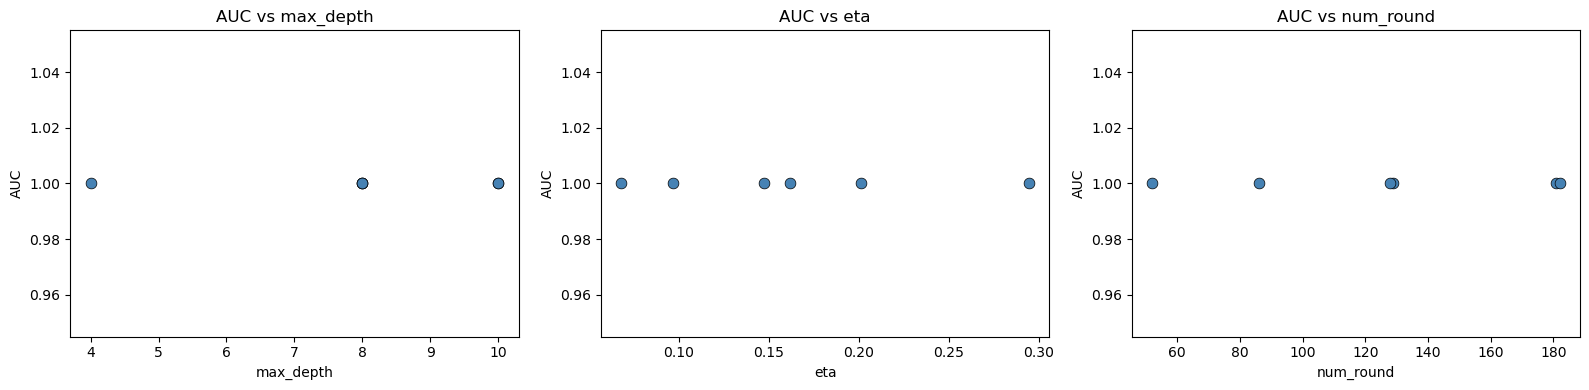

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, param in enumerate(["max_depth", "eta", "num_round"]):
    if param in hpo_results.columns:
        axes[idx].scatter(
            hpo_results[param].astype(float),
            hpo_results["FinalObjectiveValue"],
            c="steelblue", s=60, edgecolors="black", linewidth=0.5,
        )
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel("AUC")
        axes[idx].set_title(f"AUC vs {param}")

plt.tight_layout()
plt.show()

## Connecting HPO to Wednesday's Experiment Tracking

On Wednesday you learned to track experiments with SageMaker Experiments -- manually logging hyperparameters, metrics, and artifacts for each training run. HPO automates that process:

| Aspect | Manual Experiments (Wednesday) | HPO (Today) |
|--------|-------------------------------|-------------|
| **Who chooses hyperparameters** | You | Bayesian optimizer |
| **Number of trials** | As many as you run | Configured (`max_jobs`) |
| **Learning between trials** | Your intuition | Probabilistic model |
| **Tracking** | Explicit logging | Automatic |
| **Best practice** | Exploration, understanding | Exploitation, optimization |

**Production pattern:** Use manual experiments to explore the problem space and narrow down reasonable hyperparameter ranges. Then use HPO to fine-tune within those ranges. Log both manual experiments and HPO trials in the same experiment for a complete record.

> **Discussion:** Wednesday you manually tracked experiments. Today HPO automated the process. What are the trade-offs? (Manual gives intuition and control -- you learn what matters. HPO is systematic but costs more compute. Best practice: manual exploration first, then HPO to fine-tune.)

## Cleanup

> **What is happening:** We clean up any resources created during this notebook. HPO may have created model artifacts but we did not deploy any endpoints in Stage 3. We verify no active endpoints remain from any stage.

In [ ]:
sm_client = boto3.client("sagemaker")

endpoints = sm_client.list_endpoints(
    StatusEquals="InService",
    MaxResults=20,
)["Endpoints"]

fraudshield_endpoints = [
    ep for ep in endpoints
    if "xgboost" in ep["EndpointName"].lower()
    or "kmeans" in ep["EndpointName"].lower()
    or "randomcutforest" in ep["EndpointName"].lower()
    or "rcf" in ep["EndpointName"].lower()
]

if fraudshield_endpoints:
    print("Deleting active endpoints:")
    for ep in fraudshield_endpoints:
        name = ep["EndpointName"]
        print(f"  Deleting {name}...")
        sm_client.delete_endpoint(EndpointName=name)
        try:
            sm_client.delete_endpoint_config(EndpointConfigName=name)
        except Exception:
            pass
    print("All endpoints deleted.")
else:
    print("No active FraudShield endpoints found. All clean.")

print("\nVerify in the SageMaker console: Inference > Endpoints -- no active endpoints.")

---
## Wrap-up and Friday Preview

**Today you accomplished three things:**

1. **Trained XGBoost** as a built-in algorithm on the same fraud data from Monday. No training script -- just data and hyperparameters. You compared the results to Monday's Random Forest and saw how gradient boosting's sequential correction mechanism can outperform independent tree ensembles.

2. **Explored unsupervised algorithms.** K-Means revealed natural clusters in the fraud data. Random Cut Forest flagged anomalies without any labels. You also surveyed BlazingText for NLP and DeepAR for time series -- expanding the algorithm toolkit beyond supervised classification.

3. **Launched HPO** to systematically search for the best XGBoost hyperparameters. Bayesian optimization automated the experimentation process from Wednesday, finding better configurations than manual tuning.

**Friday Preview:** Friday wraps up the week with SageMaker Pipelines and end-to-end ML workflows. You will connect everything -- data preparation, training, evaluation, registration, and deployment -- into an automated pipeline. The manual steps you have been doing all week become reproducible, auditable DAG steps.